In [1]:
!pip install -q librosa scikit-learn matplotlib seaborn

import os
import glob
import numpy as np
import pandas as pd
import librosa
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input, Bidirectional, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2026-04-16 02:04:58.678488: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776305098.916220      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776305098.987680      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776305099.542067      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776305099.542112      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776305099.542115      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
candidate_paths = [
    "/kaggle/input/datasets/alejandropatinio/daic-woz/DAIC-WOZ",
    "/kaggle/input/daic-woz/DAIC-WOZ",
    "/kaggle/input/daic-woz-dataset/DAIC-WOZ",
]

base_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if base_path is None:
    raise FileNotFoundError(
        "DAIC-WOZ folder not found. Update candidate_paths with your dataset location."
    )

print("Using base_path:", base_path)

participant_folders = sorted(glob.glob(os.path.join(base_path, "*_P")))
print("Participant folders found:", len(participant_folders))

Using base_path: /kaggle/input/datasets/alejandropatinio/daic-woz/DAIC-WOZ
Participant folders found: 187


In [3]:
labels_candidates = [
    os.path.join(base_path, "train_split_Depression_AVEC2017.csv"),
    os.path.join(base_path, "full_train_split_Depression_AVEC2017.csv"),
]
labels_path = next((p for p in labels_candidates if os.path.exists(p)), None)

if labels_path is None:
    raise FileNotFoundError("Could not find train labels csv in DAIC-WOZ folder.")

labels_df = pd.read_csv(labels_path)
labels_df["label"] = labels_df["PHQ8_Binary"].astype(int)

print("Using labels:", labels_path)
print("Total rows:", len(labels_df))
print("Class distribution:")
print(labels_df["label"].value_counts().to_string())

Using labels: /kaggle/input/datasets/alejandropatinio/daic-woz/DAIC-WOZ/train_split_Depression_AVEC2017.csv
Total rows: 107
Class distribution:
label
0    77
1    30


In [4]:

MAX_LEN = 300   # temporal context 
N_MFCC  = 40    # spectral info
SR      = 16000

def extract_features(file_path, max_len=MAX_LEN, n_mfcc=N_MFCC, sr=SR):
    """
    Extract 40 MFCCs + delta + delta-delta = 120 features per frame.
    Apply per-sample z-normalization.
    Pad or truncate to max_len time steps.
    """
    try:
        y_audio, _ = librosa.load(file_path, sr=sr)

        # Remove silence from start/end (helps with varying interview lengths)
        y_audio, _ = librosa.effects.trim(y_audio, top_db=25)

        # MFCC
        mfcc = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=n_mfcc)

        # Delta and delta-delta
        delta  = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)

        # Stack: (120, T)
        features = np.concatenate([mfcc, delta, delta2], axis=0)

        features = features.T

        # Per-sample z-normalization (zero mean, unit variance)
        mean = features.mean(axis=0, keepdims=True)
        std  = features.std(axis=0, keepdims=True) + 1e-8
        features = (features - mean) / std

        if features.shape[0] < max_len:
            pad_width = max_len - features.shape[0]
            features = np.pad(features, ((0, pad_width), (0, 0)))
        else:
            features = features[:max_len]

        return features.astype(np.float32)
    except Exception as e:
        print(f"Error processing: {file_path} | {e}")
        return None

print(f"Feature config: {N_MFCC} MFCCs × 3 (mfcc+delta+delta2) = {N_MFCC*3} features")
print(f"Sequence length: {MAX_LEN} time steps")

Feature config: 40 MFCCs × 3 (mfcc+delta+delta2) = 120 features
Sequence length: 300 time steps


In [5]:
X_list = []
y_list = []
missing_count = 0

for _, row in tqdm(labels_df.iterrows(), total=len(labels_df), desc="Extracting features"):
    pid = int(row["Participant_ID"])
    label = int(row["label"])

    file_path = os.path.join(base_path, f"{pid}_P", f"{pid}_AUDIO.wav")

    if os.path.exists(file_path):
        features = extract_features(file_path)
        if features is not None:
            X_list.append(features)
            y_list.append(label)
    else:
        missing_count += 1

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)

print(f"\nCollected samples: {len(X)}")
print(f"Missing audio files: {missing_count}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class counts: {dict(zip(*np.unique(y, return_counts=True)))}")

Extracting features: 100%|██████████| 107/107 [02:47<00:00,  1.57s/it]


Collected samples: 107
Missing audio files: 0
X shape: (107, 300, 120)
y shape: (107,)
Class counts: {np.int32(0): np.int64(77), np.int32(1): np.int64(30)}


In [6]:
def augment_audio(file_path, sr=SR):
    """Apply random augmentation to an audio file and return augmented waveform."""
    y_audio, _ = librosa.load(file_path, sr=sr)
    y_audio, _ = librosa.effects.trim(y_audio, top_db=25)

    # Random augmentation choice
    aug_type = np.random.choice(['stretch', 'pitch', 'noise', 'combo'])

    if aug_type == 'stretch' or aug_type == 'combo':
        rate = np.random.uniform(0.85, 1.15)
        y_audio = librosa.effects.time_stretch(y_audio, rate=rate)

    if aug_type == 'pitch' or aug_type == 'combo':
        n_steps = np.random.uniform(-2, 2)
        y_audio = librosa.effects.pitch_shift(y_audio, sr=sr, n_steps=n_steps)

    if aug_type == 'noise' or aug_type == 'combo':
        noise = np.random.randn(len(y_audio)) * 0.005
        y_audio = y_audio + noise

    return y_audio


def extract_features_from_waveform(y_audio, sr=SR, max_len=MAX_LEN, n_mfcc=N_MFCC):
    """Same feature extraction but from a waveform array instead of file."""
    try:
        mfcc = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=n_mfcc)
        delta  = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)
        features = np.concatenate([mfcc, delta, delta2], axis=0).T

        mean = features.mean(axis=0, keepdims=True)
        std  = features.std(axis=0, keepdims=True) + 1e-8
        features = (features - mean) / std

        if features.shape[0] < max_len:
            features = np.pad(features, ((0, max_len - features.shape[0]), (0, 0)))
        else:
            features = features[:max_len]

        return features.astype(np.float32)
    except:
        return None


# Augment minority class (label=1) to balance the dataset
class_0_count = int((y == 0).sum())
class_1_count = int((y == 1).sum())
augment_needed = class_0_count - class_1_count  # how many extra class-1 samples we need

print(f"Before augmentation: class 0 = {class_0_count}, class 1 = {class_1_count}")
print(f"Augmenting {augment_needed} additional class-1 samples...")

# Get depressed participant IDs and their file paths
dep_pids = labels_df[labels_df["label"] == 1]["Participant_ID"].values
dep_paths = []
for pid in dep_pids:
    fp = os.path.join(base_path, f"{int(pid)}_P", f"{int(pid)}_AUDIO.wav")
    if os.path.exists(fp):
        dep_paths.append(fp)

X_aug = []
y_aug = []

for i in tqdm(range(augment_needed), desc="Augmenting class 1"):
    # Cycle through depressed audio files
    path = dep_paths[i % len(dep_paths)]
    try:
        aug_waveform = augment_audio(path)
        feats = extract_features_from_waveform(aug_waveform)
        if feats is not None:
            X_aug.append(feats)
            y_aug.append(1)
    except Exception as e:
        print(f"Augmentation error: {e}")

if X_aug:
    X_aug = np.array(X_aug, dtype=np.float32)
    y_aug = np.array(y_aug, dtype=np.int32)
    X = np.concatenate([X, X_aug], axis=0)
    y = np.concatenate([y, y_aug], axis=0)

print(f"\nAfter augmentation: X shape = {X.shape}")
print(f"Class counts: {dict(zip(*np.unique(y, return_counts=True)))}")

Before augmentation: class 0 = 77, class 1 = 30
Augmenting 47 additional class-1 samples...


Augmenting class 1: 100%|██████████| 47/47 [03:52<00:00,  4.96s/it]


After augmentation: X shape = (154, 300, 120)
Class counts: {np.int32(0): np.int64(77), np.int32(1): np.int64(77)}


In [7]:
# Shuffle the combined data
shuffle_idx = np.random.RandomState(42).permutation(len(X))
X = X[shuffle_idx]
y = y[shuffle_idx]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print(f"Train:      {X_tr.shape}  | class counts: {dict(zip(*np.unique(y_tr, return_counts=True)))}")
print(f"Validation: {X_val.shape} | class counts: {dict(zip(*np.unique(y_val, return_counts=True)))}")
print(f"Test:       {X_test.shape} | class counts: {dict(zip(*np.unique(y_test, return_counts=True)))}")

Train:      (98, 300, 120)  | class counts: {np.int32(0): np.int64(49), np.int32(1): np.int64(49)}
Validation: (25, 300, 120) | class counts: {np.int32(0): np.int64(12), np.int32(1): np.int64(13)}
Test:       (31, 300, 120) | class counts: {np.int32(0): np.int64(16), np.int32(1): np.int64(15)}


In [8]:
N_FEATURES = N_MFCC * 3  # 120

model = Sequential([
    Input(shape=(MAX_LEN, N_FEATURES)),

    # First BiLSTM block
    Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)),
    BatchNormalization(),

    # Second BiLSTM block
    Bidirectional(LSTM(64, return_sequences=False, dropout=0.3, recurrent_dropout=0.2)),
    BatchNormalization(),

    # Dense head
    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.4),
    Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.summary()

I0000 00:00:1776305526.863795      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776305526.869771      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 300, 256)       │       254,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,233 (1.65 MB)

 Trainable params: 430,465 (1.64 MB)

 Non-trainable params: 768 (3.00 KB)

In [9]:
os.makedirs("models", exist_ok=True)

classes = np.unique(y_tr)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weight_dict)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",  # monitor LOSS
        mode="min",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,  # patience before reducing LR
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        "models/best_depression_model.keras",
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

model.save("models/depression_model.keras")
print("\nSaved: models/depression_model.keras & models/best_depression_model.keras")

Class weights: {0: 1.0, 1: 1.0}
Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5200 - loss: 0.8823 - precision: 0.4955 - recall: 0.3887
Epoch 1: val_loss improved from inf to 0.69951, saving model to models/best_depression_model.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.5226 - loss: 0.8834 - precision: 0.5020 - recall: 0.3988 - val_accuracy: 0.6400 - val_loss: 0.6995 - val_precision: 0.7500 - val_recall: 0.4615 - learning_rate: 5.0000e-04
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4596 - loss: 0.8573 - precision: 0.5054 - recall: 0.3639
Epoch 2: val_loss did not improve from 0.69951
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.4633 - loss: 0.8620 - precision: 0.5032 - recall: 0.3694 - val_accuracy: 0.5600 - val_loss: 0.7005 - val_precision: 0.6250 - val_recall: 0.3846 - learning_rate: 5.0000e-04
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4930 - loss: 0.8135 - precision: 0.5092 - recall: 0.4490
Epoch 3: val_loss d

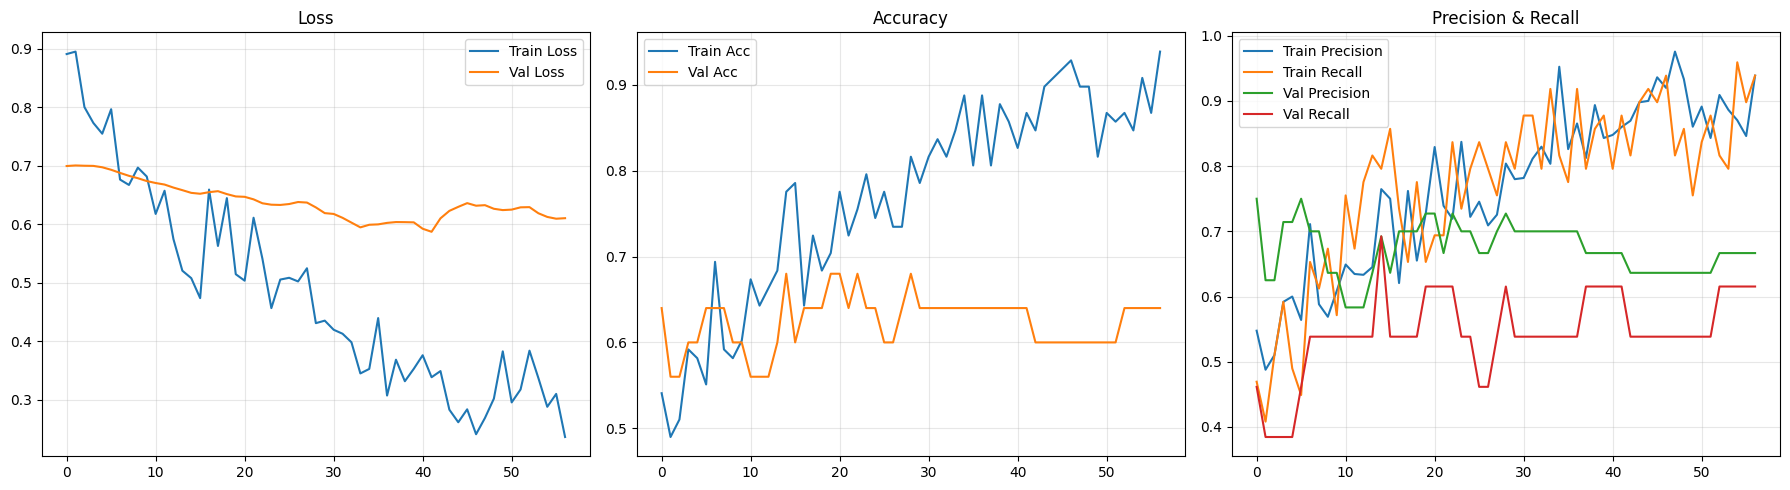

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Precision & Recall
axes[2].plot(history.history['precision'], label='Train Precision')
axes[2].plot(history.history['recall'], label='Train Recall')
axes[2].plot(history.history['val_precision'], label='Val Precision')
axes[2].plot(history.history['val_recall'], label='Val Recall')
axes[2].set_title('Precision & Recall')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Load best model
best_model = tf.keras.models.load_model("models/best_depression_model.keras")

loss, acc, prec, rec = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall   : {rec:.4f}")

# Check raw predictions
y_prob = best_model.predict(X_test, verbose=0).ravel()
print(f"\nPrediction stats: min={y_prob.min():.4f}, max={y_prob.max():.4f}, mean={y_prob.mean():.4f}")
print(f"Predictions >= 0.5: {(y_prob >= 0.5).sum()} out of {len(y_prob)}")

Test Loss     : 0.5177
Test Accuracy : 0.7742
Test Precision: 0.7857
Test Recall   : 0.7333

Prediction stats: min=0.0234, max=0.9477, mean=0.4448
Predictions >= 0.5: 14 out of 31


 threshold       f1  accuracy
      0.20 0.736842  0.677419
      0.22 0.736842  0.677419
      0.24 0.736842  0.677419
      0.26 0.756757  0.709677
      0.28 0.756757  0.709677
      0.30 0.742857  0.709677
      0.32 0.742857  0.709677
      0.34 0.764706  0.741935
      0.36 0.764706  0.741935
      0.38 0.750000  0.741935
      0.40 0.750000  0.741935
      0.42 0.733333  0.741935
      0.44 0.733333  0.741935
      0.46 0.733333  0.741935
      0.48 0.758621  0.774194
      0.50 0.758621  0.774194
      0.52 0.714286  0.741935
      0.54 0.666667  0.709677
      0.56 0.666667  0.709677
      0.58 0.692308  0.741935
      0.60 0.720000  0.774194
      0.62 0.720000  0.774194
      0.64 0.666667  0.741935
      0.66 0.636364  0.741935
      0.68 0.636364  0.741935
      0.70 0.571429  0.709677

Best threshold (F1): 0.34 | F1: 0.7647


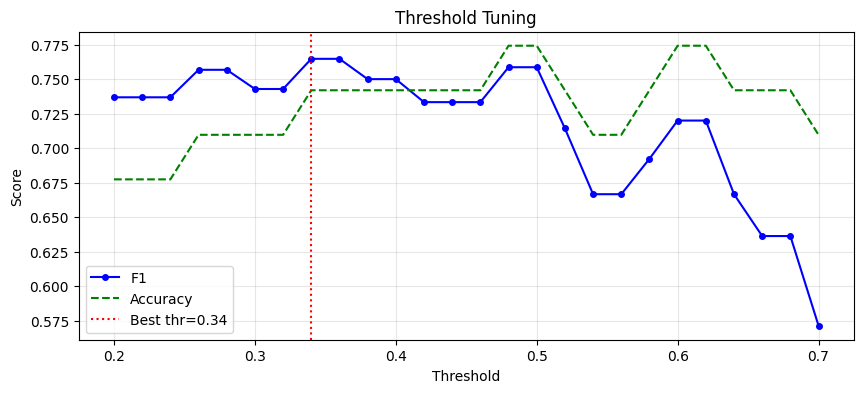

In [12]:
# Optimal threshold search (F1 score)
y_prob = best_model.predict(X_test, verbose=0).ravel()

best_thr = 0.50
best_f1 = -1.0
results = []

for thr in np.arange(0.20, 0.71, 0.02):
    y_pred_thr = (y_prob >= thr).astype(int)
    f1 = f1_score(y_test, y_pred_thr, zero_division=0)
    acc_thr = (y_pred_thr == y_test).mean()
    results.append({'threshold': thr, 'f1': f1, 'accuracy': acc_thr})
    if f1 > best_f1:
        best_f1 = float(f1)
        best_thr = float(thr)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print(f"\n{'='*50}")
print(f"Best threshold (F1): {best_thr:.2f} | F1: {best_f1:.4f}")
print(f"{'='*50}")

# Plot threshold vs F1
plt.figure(figsize=(10, 4))
plt.plot(results_df['threshold'], results_df['f1'], 'b-o', markersize=4, label='F1')
plt.plot(results_df['threshold'], results_df['accuracy'], 'g--', markersize=4, label='Accuracy')
plt.axvline(x=best_thr, color='r', linestyle=':', label=f'Best thr={best_thr:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Using threshold: 0.34

               precision    recall  f1-score   support

Not Depressed     0.8333    0.6250    0.7143        16
    Depressed     0.6842    0.8667    0.7647        15

     accuracy                         0.7419        31
    macro avg     0.7588    0.7458    0.7395        31
 weighted avg     0.7612    0.7419    0.7387        31



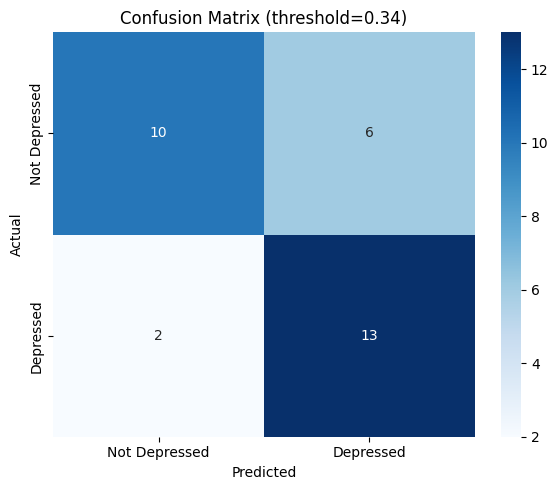


✅ Final F1 (class 1): 0.7647


In [13]:
y_pred = (y_prob >= best_thr).astype(int)

print(f"Using threshold: {best_thr:.2f}")
print("\n" + classification_report(y_test, y_pred, target_names=['Not Depressed', 'Depressed'], digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Depressed', 'Depressed'],
            yticklabels=['Not Depressed', 'Depressed'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (threshold={best_thr:.2f})')
plt.tight_layout()
plt.show()

print(f"\n✅ Final F1 (class 1): {f1_score(y_test, y_pred, zero_division=0):.4f}")